# CBCL Severity Prediction with XLM-RoBERTa and CORN

This notebook develops and evaluates the transformer-based modeling pipeline for predicting child CBCL severity (Low / Medium / High) from parent-written text.

The final model uses XLM-RoBERTa with a frozen transformer backbone and class rebalancing through moderate oversampling. Two feature configurations are evaluated:

* Parent free-text only (Event + EER_text)
* Parent free-text + child age

The notebook also documents the model-development process, performs quantitative and qualitative model analysis, and evaluates an ordinal CORN formulation as the research extension.

Reusable preprocessing and modeling functions are maintained separately in the repository's `src/` directory.

In [3]:
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/OfriA/AppliedProject52056.git"
REPO_DIR = Path("/content/AppliedProject52056")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)

SRC_DIR = REPO_DIR / "src"

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Could not find src/ in {REPO_DIR}")

sys.path.insert(0, str(SRC_DIR))

print(f"Using source files from: {SRC_DIR}")

Using source files from: /content/AppliedProject52056/src


## 1. Setup and Data Preparation

In [ ]:
!pip install -q transformers datasets accelerate

In [5]:
from data_utils import (
    prepare_dataset,
    split_data,
    create_cbcl_labels,
)

from embeddings import load_or_create_embeddings

from modeling import (
    train_logistic_regression,
    evaluate_model,
)

In [ ]:
df = prepare_dataset()

train_df, test_df = split_data(df)

train_df, test_df, t1, t2 = create_cbcl_labels(
    train_df,
    test_df
)

print("CBCL thresholds:")
print("t1:", t1)
print("t2:", t2)

print("\nTrain labels:")
print(train_df["CBCL_label"].value_counts())

print("\nTest labels:")
print(test_df["CBCL_label"].value_counts())

CBCL thresholds:
t1: 13.0
t2: 30.0

Train labels:
CBCL_label
Low       112
Medium     73
High       31
Name: count, dtype: int64

Test labels:
CBCL_label
Low       24
Medium    21
High       9
Name: count, dtype: int64


### 1.1 Logistic Regression Baseline Reference

In [ ]:
X_train, X_test = load_or_create_embeddings(
    train_df,
    test_df
)

Loading cached embeddings...


In [ ]:
y_train = train_df["CBCL_label"].values
y_test = test_df["CBCL_label"].values

real_model = train_logistic_regression(
    X_train,
    y_train,
    use_grid_search=True
)

real_pred = real_model.predict(X_test)

real_results = evaluate_model(
    "Baseline: LogReg",
    y_test,
    real_pred
)

real_results

Best params: {'C': 3}
Best CV High F2: 0.23177803379416279


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Model': 'Baseline: LogReg',
 'Macro F1': 0.3680155108726537,
 'Low Precision': 0.48,
 'Low Recall': 0.5,
 'Low F2': 0.49586776859504134,
 'Medium Precision': 0.5,
 'Medium Recall': 0.38095238095238093,
 'Medium F2': 0.4,
 'High Precision': 0.15384615384615385,
 'High Recall': 0.2222222222222222,
 'High F2': 0.20408163265306123,
 'ConfusionMatrix': array([[12,  7,  5],
        [ 7,  8,  6],
        [ 6,  1,  2]])}

## 2. XLM-RoBERTa Experiments

### 2.1 Model Development

In [ ]:
import numpy as np
import pandas as pd

from transformers_modeling import (
    run_transformer_experiment,
    LABELS,
    summarize_results,
    build_input_text
)

#### 2.1.1 Initial Fine-Tuning

In [ ]:
results_event_eer = run_transformer_experiment(
    train_df=train_df,
    test_df=test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    output_dir="./transformer_event_eer",
    max_length=384,
    num_epochs=10,
    batch_size=8,
    learning_rate=3e-3
)

Running transformer experiment
Mode: event_eer
Model: xlm-roberta-base
Freeze base model: False
Oversample inner train: False
Metadata columns: None
Checkpoint saving: DISABLED

Before oversampling:
Low       89
Medium    58
High      25
Name: count, dtype: int64

Final data sizes:
Inner train size: 172
Validation size: 44
Test size: 54


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,High Precision,High Recall,High F2
1,1.789183,2.304174,0.340909,0.169492,0.000000,0.000000,0.000000
2,1.560561,1.260272,0.136364,0.080000,0.136364,1.000000,0.441176
3,1.326364,1.121787,0.522727,0.228856,0.000000,0.000000,0.000000
4,1.410685,1.513849,0.136364,0.080000,0.136364,1.000000,0.441176
5,1.169129,1.138722,0.340909,0.169492,0.000000,0.000000,0.000000
6,1.238697,1.190406,0.340909,0.169492,0.000000,0.000000,0.000000
7,1.250035,1.121478,0.340909,0.169492,0.000000,0.000000,0.000000
8,1.109799,1.198203,0.340909,0.169492,0.000000,0.000000,0.000000
9,1.138866,1.092113,0.522727,0.228856,0.000000,0.000000,0.000000
10,1.133717,1.090705,0.522727,0.228856,0.000000,0.000000,0.000000



Validation evaluation after final epoch:


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,High Precision,High Recall,High F2
1.133717,1.090705,10,0.522727,0.228856,0.000000,0.000000,0.000000


{'eval_loss': 1.0907046794891357, 'eval_accuracy': 0.5227272727272727, 'eval_macro_f1': 0.2288557213930348, 'eval_high_precision': 0.0, 'eval_high_recall': 0.0, 'eval_high_f2': 0.0}



TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.44      1.00      0.62        24
      Medium       0.00      0.00      0.00        21
        High       0.00      0.00      0.00         9

    accuracy                           0.44        54
   macro avg       0.15      0.33      0.21        54
weighted avg       0.20      0.44      0.27        54


TEST SUMMARY METRICS
Accuracy:        0.444
Macro F1:        0.205
High Precision:  0.000
High Recall:     0.000
High F2:         0.000

TEST CONFUSION MATRIX
             Pred Low  Pred Medium  Pred High
True Low           24            0          0
True Medium        21            0          0
True High           9            0          0


In [ ]:
print("TEST METRICS")
print("Accuracy:", results_event_eer["accuracy"])
print("Macro F1:", results_event_eer["macro_f1"])
print("High Precision:", results_event_eer["high_precision"])
print("High Recall:", results_event_eer["high_recall"])
print("High F2:", results_event_eer["high_f2"])

TEST METRICS
Accuracy: 0.4444444444444444
Macro F1: 0.20512820512820515
High Precision: 0.0
High Recall: 0.0
High F2: 0.0


The initial fine-tuning setup produced a strong bias toward the majority class and failed to identify High-CBCL cases. We therefore froze the transformer backbone and trained only the classification head to reduce overfitting on the relatively small training set.

#### 2.1.2 Frozen Backbone

In [ ]:
results_event_eer_frozen = run_transformer_experiment(
    train_df=train_df,
    test_df=test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    output_dir="./transformer_event_eer_frozen",
    max_length=256,
    num_epochs=20,
    batch_size=8,
    learning_rate=1e-3,
    freeze_base_model=True
)

Running transformer experiment
Mode: event_eer
Model: xlm-roberta-base
Freeze base model: True
Oversample inner train: False
Metadata columns: None
Checkpoint saving: DISABLED

Before oversampling:
Low       89
Medium    58
High      25
Name: count, dtype: int64

Final data sizes:
Inner train size: 172
Validation size: 44
Test size: 54


Map:   0%|          | 0/172 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]


Class counts used for training:
[89 58 25]
Class weights:
[0.64419476 0.98850575 2.29333333]


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,High Precision,High Recall,High F2
1,1.300061,1.157629,0.113636,0.092478,0.111111,0.666667,0.333333
2,1.158496,1.117563,0.363636,0.203216,0.000000,0.000000,0.000000
3,1.194020,1.214710,0.136364,0.080000,0.136364,1.000000,0.441176
4,1.173632,1.134205,0.159091,0.109410,0.139535,1.000000,0.447761
5,1.107001,1.160361,0.363636,0.200192,0.000000,0.000000,0.000000
6,1.184904,1.094643,0.386364,0.228772,0.000000,0.000000,0.000000
7,1.119585,1.108044,0.181818,0.160781,0.108108,0.666667,0.327869
8,1.088777,1.160680,0.340909,0.169492,0.000000,0.000000,0.000000
9,1.091173,1.091697,0.568182,0.393333,0.000000,0.000000,0.000000
10,1.135673,1.127559,0.181818,0.136667,0.142857,1.000000,0.454545



Validation evaluation after final epoch:


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,High Precision,High Recall,High F2
1.028680,1.102573,20,0.522727,0.376125,0.000000,0.000000,0.000000


{'eval_loss': 1.1025725603103638, 'eval_accuracy': 0.5227272727272727, 'eval_macro_f1': 0.3761246434057494, 'eval_high_precision': 0.0, 'eval_high_recall': 0.0, 'eval_high_f2': 0.0}



TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.50      0.71      0.59        24
      Medium       0.50      0.43      0.46        21
        High       0.00      0.00      0.00         9

    accuracy                           0.48        54
   macro avg       0.33      0.38      0.35        54
weighted avg       0.42      0.48      0.44        54


TEST SUMMARY METRICS
Accuracy:        0.481
Macro F1:        0.349
High Precision:  0.000
High Recall:     0.000
High F2:         0.000

TEST CONFUSION MATRIX
             Pred Low  Pred Medium  Pred High
True Low           17            6          1
True Medium        11            9          1
True High           6            3          0


In [ ]:
print("TEST METRICS")
print("Accuracy:", results_event_eer_frozen["accuracy"])
print("Macro F1:", results_event_eer_frozen["macro_f1"])
print("High Precision:", results_event_eer_frozen["high_precision"])
print("High Recall:", results_event_eer_frozen["high_recall"])
print("High F2:", results_event_eer_frozen["high_f2"])

TEST METRICS
Accuracy: 0.48148148148148145
Macro F1: 0.34924845269672855
High Precision: 0.0
High Recall: 0.0
High F2: 0.0


Freezing the backbone improved overall class separation, but the model still failed to identify High-CBCL cases. To address the remaining class imbalance, we next introduced oversampling of the minority classes.

#### 2.1.3 Full Oversampling

In [ ]:
results_event_eer_resampled = run_transformer_experiment(
    train_df=train_df,
    test_df=test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    output_dir="./transformer_event_eer_resampled",
    max_length=384,
    num_epochs=20,
    batch_size=8,
    learning_rate=1e-3,
    freeze_base_model=True,
    oversample_train=True
)

Running transformer experiment
Mode: event_eer
Model: xlm-roberta-base
Freeze base model: True
Oversample inner train: True
Metadata columns: None
Checkpoint saving: DISABLED

Before oversampling:
Low       89
Medium    58
High      25
Name: count, dtype: int64

After oversampling:
Low       89
High      89
Medium    89
Name: count, dtype: int64

Final data sizes:
Inner train size: 267
Validation size: 44
Test size: 54


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,High Precision,High Recall,High F2
1,1.187576,1.231341,0.340909,0.172414,0.000000,0.000000,0.000000
2,1.165002,1.301538,0.159091,0.109410,0.139535,1.000000,0.447761
3,1.112436,1.050311,0.409091,0.255495,0.000000,0.000000,0.000000
4,1.095547,1.284267,0.204545,0.157859,0.055556,0.166667,0.119048
5,1.091930,1.227845,0.181818,0.136667,0.142857,1.000000,0.454545
6,1.045701,1.033703,0.522727,0.364706,0.000000,0.000000,0.000000
7,1.060556,1.205212,0.250000,0.235450,0.138889,0.833333,0.416667
8,1.046221,1.107889,0.340909,0.231838,0.000000,0.000000,0.000000
9,1.045927,1.012206,0.545455,0.303226,0.000000,0.000000,0.000000
10,0.983539,1.126625,0.386364,0.329189,0.090909,0.166667,0.142857



Validation evaluation after final epoch:


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,High Precision,High Recall,High F2
0.867981,1.181665,20,0.295455,0.289642,0.095238,0.333333,0.222222


{'eval_loss': 1.1816645860671997, 'eval_accuracy': 0.29545454545454547, 'eval_macro_f1': 0.28964245630912294, 'eval_high_precision': 0.09523809523809523, 'eval_high_recall': 0.3333333333333333, 'eval_high_f2': 0.2222222222222222}



TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.57      0.17      0.26        24
      Medium       0.50      0.29      0.36        21
        High       0.14      0.56      0.23         9

    accuracy                           0.28        54
   macro avg       0.40      0.34      0.28        54
weighted avg       0.47      0.28      0.29        54


TEST SUMMARY METRICS
Accuracy:        0.278
Macro F1:        0.283
High Precision:  0.143
High Recall:     0.556
High F2:         0.352

TEST CONFUSION MATRIX
             Pred Low  Pred Medium  Pred High
True Low            4            4         16
True Medium         1            6         14
True High           2            2          5


In [ ]:
print("TEST METRICS")
print("Accuracy:", results_event_eer_resampled["accuracy"])
print("Macro F1:", results_event_eer_resampled["macro_f1"])
print("High Precision:", results_event_eer_resampled["high_precision"])
print("High Recall:", results_event_eer_resampled["high_recall"])
print("High F2:", results_event_eer_resampled["high_f2"])

TEST METRICS
Accuracy: 0.2777777777777778
Macro F1: 0.2829912023460411
High Precision: 0.14285714285714285
High Recall: 0.5555555555555556
High F2: 0.352112676056338


Full class balancing substantially increased recall for the High class, but degraded overall multiclass performance. We therefore replaced full balancing with moderate oversampling, aiming to improve minority-class detection while preserving overall discrimination.

#### 2.1.4 Moderate Oversampling

In [ ]:
results_event_eer_partial_50 = run_transformer_experiment(
    train_df=train_df,
    test_df=test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    output_dir="./transformer_event_eer_partial_50",
    max_length=384,
    num_epochs=20,
    batch_size=8,
    learning_rate=1e-3,
    freeze_base_model=True,
    oversample_train=True,
    oversample_target_counts={
        0: 89,  # Low
        1: 70,  # Medium
        2: 50   # High
    }
)

Running transformer experiment
Mode: event_eer
Model: xlm-roberta-base
Freeze base model: True
Oversample inner train: True
Metadata columns: None
Checkpoint saving: DISABLED

Before oversampling:
Low       89
Medium    58
High      25
Name: count, dtype: int64

After oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64

Final data sizes:
Inner train size: 209
Validation size: 44
Test size: 54


Map:   0%|          | 0/209 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]


Class counts used for training:
[89 70 50]
Class weights:
[0.78277154 0.9952381  1.39333333]


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,High Precision,High Recall,High F2
1,1.280073,1.188867,0.340909,0.169492,0.000000,0.000000,0.000000
2,1.213670,1.067040,0.477273,0.342105,0.000000,0.000000,0.000000
3,1.097647,1.070279,0.568182,0.367251,0.000000,0.000000,0.000000
4,1.142831,1.316729,0.340909,0.169492,0.000000,0.000000,0.000000
5,1.192266,1.128989,0.340909,0.197475,0.000000,0.000000,0.000000
6,1.072196,1.134737,0.363636,0.200192,0.000000,0.000000,0.000000
7,1.091308,1.154184,0.295455,0.265873,0.136364,0.500000,0.326087
8,1.059144,1.199166,0.136364,0.080000,0.136364,1.000000,0.441176
9,1.060213,1.051557,0.500000,0.362637,0.000000,0.000000,0.000000
10,1.023277,1.214024,0.227273,0.183684,0.096774,0.500000,0.272727



Validation evaluation after final epoch:


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,High Precision,High Recall,High F2
0.939522,1.068162,20,0.500000,0.424874,0.166667,0.166667,0.166667


{'eval_loss': 1.0681616067886353, 'eval_accuracy': 0.5, 'eval_macro_f1': 0.4248737373737374, 'eval_high_precision': 0.16666666666666666, 'eval_high_recall': 0.16666666666666666, 'eval_high_f2': 0.16666666666666666}



TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.61      0.71      0.65        24
      Medium       0.56      0.48      0.51        21
        High       0.12      0.11      0.12         9

    accuracy                           0.52        54
   macro avg       0.43      0.43      0.43        54
weighted avg       0.51      0.52      0.51        54


TEST SUMMARY METRICS
Accuracy:        0.519
Macro F1:        0.428
High Precision:  0.125
High Recall:     0.111
High F2:         0.114

TEST CONFUSION MATRIX
             Pred Low  Pred Medium  Pred High
True Low           17            5          2
True Medium         6           10          5
True High           5            3          1


In [ ]:
print("TEST METRICS")
print("Accuracy:", results_event_eer_partial_50["accuracy"])
print("Macro F1:", results_event_eer_partial_50["macro_f1"])
print("High Precision:", results_event_eer_partial_50["high_precision"])
print("High Recall:", results_event_eer_partial_50["high_recall"])
print("High F2:", results_event_eer_partial_50["high_f2"])

TEST METRICS
Accuracy: 0.5185185185185185
Macro F1: 0.42810457516339867
High Precision: 0.125
High Recall: 0.1111111111111111
High F2: 0.11363636363636363


The moderate-oversampling configuration provided a better compromise between overall Macro F1 and sensitivity to the High class, and was therefore retained as the final text-only XLM-RoBERTa configuration.

### 2.2 Text + Child Age

For the second feature set, child age was added to the Event and EER_text input as structured metadata, while keeping the same frozen-backbone and moderate-oversampling configuration used for the text-only model.

In [ ]:
example_text = build_input_text(
    train_df.head(1),
    mode="event_eer",
    metadata_columns=["child_age"]
)[0]

print(example_text)

EVENT: העברת הרגשת החוסר אונים שאין יכולת לשנות ככעס לילדים

EER_TEXT: אני כמה שברצוני לשנות את המצב אין יכולת לכך מה שהכי נכון זה לדאוג לחוויה רכועה במסגאת הבית לשמור על שיגרה ולהיות שמח .
כך האנרגיה תעבור לבני הבית והכל יהיה לטובה 

METADATA: child_age=12


In [ ]:
results_event_eer_meta_partial_50 = run_transformer_experiment(
    train_df=train_df,
    test_df=test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    output_dir="./transformer_event_eer_meta_partial_50",
    max_length=384,
    num_epochs=20,
    batch_size=8,
    learning_rate=1e-3,
    freeze_base_model=True,
    oversample_train=True,
    oversample_target_counts={
        0: 89,
        1: 70,
        2: 50
    },
    metadata_columns=["child_age"]
)

Running transformer experiment
Mode: event_eer
Model: xlm-roberta-base
Freeze base model: True
Oversample inner train: True
Metadata columns: ['child_age']
Checkpoint saving: DISABLED

Before oversampling:
Low       89
Medium    58
High      25
Name: count, dtype: int64

After oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64

Final data sizes:
Inner train size: 209
Validation size: 44
Test size: 54


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/209 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,High Precision,High Recall,High F2
1,1.297978,1.177658,0.340909,0.169492,0.000000,0.000000,0.000000
2,1.219047,1.098696,0.340909,0.169492,0.000000,0.000000,0.000000
3,1.167985,1.157573,0.340909,0.169492,0.000000,0.000000,0.000000
4,1.164995,1.182923,0.340909,0.169492,0.000000,0.000000,0.000000
5,1.132904,1.095951,0.409091,0.323077,0.250000,0.166667,0.178571
6,1.106690,1.065768,0.363636,0.200192,0.000000,0.000000,0.000000
7,1.104055,1.204753,0.136364,0.080000,0.136364,1.000000,0.441176
8,1.100638,1.218680,0.136364,0.080000,0.136364,1.000000,0.441176
9,1.079230,1.082798,0.454545,0.270968,0.250000,0.166667,0.178571
10,1.106690,1.122327,0.340909,0.206734,0.083333,0.166667,0.138889



Validation evaluation after final epoch:


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,High Precision,High Recall,High F2
0.960890,1.069818,20,0.522727,0.438924,0.166667,0.166667,0.166667


{'eval_loss': 1.0698180198669434, 'eval_accuracy': 0.5227272727272727, 'eval_macro_f1': 0.4389241249706366, 'eval_high_precision': 0.16666666666666666, 'eval_high_recall': 0.16666666666666666, 'eval_high_f2': 0.16666666666666666}



TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.60      0.62      0.61        24
      Medium       0.56      0.43      0.49        21
        High       0.38      0.56      0.45         9

    accuracy                           0.54        54
   macro avg       0.52      0.54      0.52        54
weighted avg       0.55      0.54      0.54        54


TEST SUMMARY METRICS
Accuracy:        0.537
Macro F1:        0.518
High Precision:  0.385
High Recall:     0.556
High F2:         0.510

TEST CONFUSION MATRIX
             Pred Low  Pred Medium  Pred High
True Low           15            5          4
True Medium         8            9          4
True High           2            2          5


In [ ]:
print("TEST METRICS")
print("Accuracy:", results_event_eer_meta_partial_50["accuracy"])
print("Macro F1:", results_event_eer_meta_partial_50["macro_f1"])
print("High Precision:", results_event_eer_meta_partial_50["high_precision"])
print("High Recall:", results_event_eer_meta_partial_50["high_recall"])
print("High F2:", results_event_eer_meta_partial_50["high_f2"])

TEST METRICS
Accuracy: 0.5370370370370371
Macro F1: 0.517758946330375
High Precision: 0.38461538461538464
High Recall: 0.5555555555555556
High F2: 0.5102040816326531


In [ ]:
print("\nevent_eer_partial_50 CONFUSION MATRIX")
cm_meta = pd.DataFrame(
    results_event_eer_meta_partial_50["confusion_matrix"],
    index=[f"True {x}" for x in LABELS],
    columns=[f"Pred {x}" for x in LABELS]
)
cm_meta


event_eer_partial_50 CONFUSION MATRIX


,Pred Low,Pred Medium,Pred High
True Low,15,5,4
True Medium,8,9,4
True High,2,2,5


---

## 3. Model Analysis

### 3.1 Null Distribution Analysis


In [ ]:
import os
import gc
import shutil
import torch

from sklearn.model_selection import train_test_split

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    set_seed
)

from transformers_modeling import (
    build_input_text,
    encode_labels,
    oversample_text_labels,
    freeze_transformer_body,
    WeightedTrainer,
    compute_metrics,
    evaluate_predictions,
    LABELS,
    label2id,
    id2label
)

In [ ]:
def prepare_xlmr_null_context(
    train_df,
    test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    max_length=384,
    validation_size=0.20,
    split_seed=42,
    metadata_columns=["child_age"]
):
    """
    Prepare the fixed data split and tokenize all texts ONCE.

    Important:
    - Test labels are never changed.
    - Validation set is fixed.
    - Only inner-train labels will later be permuted.
    """

    # --------------------------------------------------
    # 1. Build exactly the same model inputs
    # --------------------------------------------------
    train_texts = np.array(
        build_input_text(
            train_df,
            mode=mode,
            metadata_columns=metadata_columns
        ),
        dtype=object
    )

    test_texts = np.array(
        build_input_text(
            test_df,
            mode=mode,
            metadata_columns=metadata_columns
        ),
        dtype=object
    )

    train_labels = np.asarray(encode_labels(train_df))
    test_labels = np.asarray(encode_labels(test_df))

    # --------------------------------------------------
    # 2. Fixed inner-train / validation split
    # --------------------------------------------------
    all_indices = np.arange(len(train_texts))

    inner_idx, val_idx = train_test_split(
        all_indices,
        test_size=validation_size,
        random_state=split_seed,
        stratify=train_labels
    )

    inner_texts = train_texts[inner_idx]
    val_texts = train_texts[val_idx]

    inner_labels = train_labels[inner_idx]
    val_labels = train_labels[val_idx]

    print("Fixed split created:")
    print("Inner train:", len(inner_idx))
    print("Validation:", len(val_idx))
    print("Test:", len(test_df))

    print("\nTrue inner-train class counts:")
    print(
        pd.Series(inner_labels)
        .map(id2label)
        .value_counts()
    )

    # --------------------------------------------------
    # 3. Tokenize ONCE
    # --------------------------------------------------
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    inner_tokens = tokenizer(
        inner_texts.tolist(),
        truncation=True,
        max_length=max_length
    )

    val_tokens = tokenizer(
        val_texts.tolist(),
        truncation=True,
        max_length=max_length
    )

    test_tokens = tokenizer(
        test_texts.tolist(),
        truncation=True,
        max_length=max_length
    )

    val_dataset = Dataset.from_dict({
        **val_tokens,
        "labels": val_labels.tolist()
    })

    test_dataset = Dataset.from_dict({
        **test_tokens,
        "labels": test_labels.tolist()
    })

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    return {
        "inner_tokens": inner_tokens,
        "inner_labels_true": inner_labels,
        "val_dataset": val_dataset,
        "test_dataset": test_dataset,
        "test_labels": test_labels,
        "tokenizer": tokenizer,
        "data_collator": data_collator,
        "model_name": model_name,
        "max_length": max_length
    }

In [ ]:
null_context = prepare_xlmr_null_context(
    train_df=train_df,
    test_df=test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    max_length=384,
    validation_size=0.20,
    split_seed=42,
    metadata_columns=["child_age"]
)

Fixed split created:
Inner train: 172
Validation: 44
Test: 54

True inner-train class counts:
Low       89
Medium    58
High      25
Name: count, dtype: int64


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
def run_xlmr_null_batch(
    context,
    start_perm,
    end_perm,
    output_csv,
    permutation_seed_base=1000,
    training_seed=42,
    oversample_target_counts={0: 89, 1: 70, 2: 50},
    num_epochs=20,
    batch_size=8,
    learning_rate=1e-3,
    weight_decay=0.01
):
    """
    Run permutations [start_perm, end_perm).

    Example:
        start_perm=0, end_perm=20
        -> permutations 0,...,19

    Each completed permutation is immediately appended to CSV.
    Therefore, if Colab crashes, completed runs are preserved.
    """

    # --------------------------------------------------
    # Resume support
    # --------------------------------------------------
    if os.path.exists(output_csv):
        existing = pd.read_csv(output_csv)

        if "permutation_id" in existing.columns:
            completed_ids = set(existing["permutation_id"].astype(int))
        else:
            completed_ids = set()

        print(
            f"Found {len(completed_ids)} already completed "
            f"permutations in {output_csv}"
        )
    else:
        completed_ids = set()

    inner_tokens = context["inner_tokens"]
    true_inner_labels = np.asarray(
        context["inner_labels_true"]
    )

    val_dataset = context["val_dataset"]
    test_dataset = context["test_dataset"]
    test_labels = np.asarray(context["test_labels"])

    tokenizer = context["tokenizer"]
    data_collator = context["data_collator"]
    model_name = context["model_name"]

    base_indices = np.arange(len(true_inner_labels))

    # --------------------------------------------------
    # Permutation loop
    # --------------------------------------------------
    for permutation_id in range(start_perm, end_perm):

        if permutation_id in completed_ids:
            print(
                f"\nPermutation {permutation_id} already exists. Skipping."
            )
            continue

        perm_seed = permutation_seed_base + permutation_id

        print("\n" + "=" * 80)
        print(
            f"Permutation {permutation_id} "
            f"(seed={perm_seed})"
        )
        print("=" * 80)

        # --------------------------------------------------
        # 1. Permute ONLY inner-train labels
        # --------------------------------------------------
        rng = np.random.default_rng(perm_seed)

        permuted_labels = rng.permutation(
            true_inner_labels
        )

        # Sanity check:
        # permutation must preserve the number of each class
        assert np.array_equal(
            np.sort(permuted_labels),
            np.sort(true_inner_labels)
        )

        # --------------------------------------------------
        # 2. Oversample AFTER permutation
        #
        # We pass observation indices into your existing
        # oversampling function. It therefore returns the
        # indices that should be duplicated.
        # --------------------------------------------------
        sampled_indices, sampled_labels = (
            oversample_text_labels(
                base_indices,
                permuted_labels,
                random_state=training_seed,
                target_counts=oversample_target_counts
            )
        )

        sampled_indices = np.asarray(
            sampled_indices,
            dtype=int
        )

        sampled_labels = np.asarray(
            sampled_labels,
            dtype=int
        )

        if permutation_id == start_perm:
            print("\nCounts after permutation + oversampling:")
            print(
                pd.Series(sampled_labels)
                .map(id2label)
                .value_counts()
            )

        # --------------------------------------------------
        # 3. Build training Dataset from PRE-TOKENIZED data
        # --------------------------------------------------
        train_dict = {
            key: [
                inner_tokens[key][i]
                for i in sampled_indices
            ]
            for key in inner_tokens.keys()
        }

        train_dict["labels"] = sampled_labels.tolist()

        train_dataset = Dataset.from_dict(train_dict)

        # --------------------------------------------------
        # 4. Same class weighting as the real pipeline
        # --------------------------------------------------
        class_counts = np.bincount(
            sampled_labels,
            minlength=len(LABELS)
        )

        if np.any(class_counts == 0):
            raise ValueError(
                f"Missing class after oversampling: "
                f"{class_counts}"
            )

        class_weights = len(sampled_labels) / (
            len(LABELS) * class_counts
        )

        # --------------------------------------------------
        # 5. Reset training randomness
        #
        # Same model initialization / training seed
        # for every permutation.
        # --------------------------------------------------
        set_seed(training_seed)

        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=len(LABELS),
            id2label=id2label,
            label2id=label2id
        )

        model = freeze_transformer_body(model)

        # Local temporary directory, not Google Drive
        temp_dir = (
            f"/content/xlmr_null_perm_{permutation_id}"
        )

        training_args = TrainingArguments(
            output_dir=temp_dir,

            eval_strategy="epoch",
            logging_strategy="epoch",

            save_strategy="no",
            load_best_model_at_end=False,

            learning_rate=learning_rate,

            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,

            num_train_epochs=num_epochs,
            weight_decay=weight_decay,

            report_to="none",
            seed=training_seed,

            disable_tqdm=True
        )

        trainer = WeightedTrainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            class_weights=class_weights
        )

        # --------------------------------------------------
        # 6. Train
        # --------------------------------------------------
        trainer.train()

        # --------------------------------------------------
        # 7. Evaluate on ORIGINAL test labels
        # --------------------------------------------------
        test_output = trainer.predict(
            test_dataset
        )

        logits = test_output.predictions
        pred_ids = np.argmax(logits, axis=1)

        y_true = [
            id2label[int(i)]
            for i in test_labels
        ]

        y_pred = [
            id2label[int(i)]
            for i in pred_ids
        ]

        metrics = evaluate_predictions(
            y_true,
            y_pred
        )

        row = pd.DataFrame([{
            "permutation_id": permutation_id,
            "permutation_seed": perm_seed,
            "training_seed": training_seed,

            "macro_f1": metrics["macro_f1"],
            "high_precision": metrics["high_precision"],
            "high_recall": metrics["high_recall"],
            "high_f2": metrics["high_f2"],
            "accuracy": metrics["accuracy"]
        }])

        print(
            f"Macro-F1 = {metrics['macro_f1']:.4f} | "
            f"High F2 = {metrics['high_f2']:.4f}"
        )

        # --------------------------------------------------
        # 8. SAVE IMMEDIATELY
        # --------------------------------------------------
        write_header = not os.path.exists(output_csv)

        row.to_csv(
            output_csv,
            mode="a",
            header=write_header,
            index=False
        )

        # --------------------------------------------------
        # 9. Aggressive memory cleanup
        # --------------------------------------------------
        del trainer
        del model
        del train_dataset
        del test_output
        del logits
        del pred_ids

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if os.path.exists(temp_dir):
            shutil.rmtree(
                temp_dir,
                ignore_errors=True
            )

    print("\nBatch complete.")

In [ ]:
run_xlmr_null_batch(
    context=null_context,
    start_perm=0,
    end_perm=20,
    output_csv="xlmr_null_000_019.csv"
)


Permutation 0 (seed=1000)

Counts after permutation + oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.233', 'grad_norm': '12.93', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.287', 'eval_accuracy': '0.1364', 'eval_macro_f1': '0.08', 'eval_high_precision': '0.1364', 'eval_high_recall': '1', 'eval_high_f2': '0.4412', 'eval_runtime': '0.5981', 'eval_samples_per_second': '73.56', 'eval_steps_per_second': '10.03', 'epoch': '1'}
{'loss': '1.255', 'grad_norm': '23.03', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.066', 'eval_accuracy': '0.5227', 'eval_macro_f1': '0.2289', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6014', 'eval_samples_per_second': '73.16', 'eval_steps_per_second': '9.976', 'epoch': '2'}
{'loss': '1.134', 'grad_norm': '13.6', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.149', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5974', 'eval_samples_per_second': '73.65', 'eval_

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.291', 'grad_norm': '9.352', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.197', 'eval_accuracy': '0.2273', 'eval_macro_f1': '0.1918', 'eval_high_precision': '0.09091', 'eval_high_recall': '0.3333', 'eval_high_f2': '0.2174', 'eval_runtime': '0.5958', 'eval_samples_per_second': '73.86', 'eval_steps_per_second': '10.07', 'epoch': '1'}
{'loss': '1.199', 'grad_norm': '11.81', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.059', 'eval_accuracy': '0.5227', 'eval_macro_f1': '0.2289', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6015', 'eval_samples_per_second': '73.15', 'eval_steps_per_second': '9.975', 'epoch': '2'}
{'loss': '1.084', 'grad_norm': '10.53', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.078', 'eval_accuracy': '0.5', 'eval_macro_f1': '0.2256', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6001', 'eval_samples_per_second': '73.33', 

In [ ]:
run_xlmr_null_batch(
    null_context,
    20,
    40,
    "xlmr_null_020_039.csv"
)


Permutation 20 (seed=1020)

Counts after permutation + oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.314', 'grad_norm': '3.491', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.124', 'eval_accuracy': '0.3182', 'eval_macro_f1': '0.2198', 'eval_high_precision': '0.09091', 'eval_high_recall': '0.1667', 'eval_high_f2': '0.1429', 'eval_runtime': '0.5748', 'eval_samples_per_second': '76.55', 'eval_steps_per_second': '10.44', 'epoch': '1'}
{'loss': '1.202', 'grad_norm': '13.61', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.167', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5979', 'eval_samples_per_second': '73.59', 'eval_steps_per_second': '10.03', 'epoch': '2'}
{'loss': '1.164', 'grad_norm': '13.29', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.157', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5946', 'eval_samples_per_second': '73.99

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.259', 'grad_norm': '10.87', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.173', 'eval_accuracy': '0.1136', 'eval_macro_f1': '0.1023', 'eval_high_precision': '0.07692', 'eval_high_recall': '0.3333', 'eval_high_f2': '0.2', 'eval_runtime': '0.5929', 'eval_samples_per_second': '74.21', 'eval_steps_per_second': '10.12', 'epoch': '1'}
{'loss': '1.196', 'grad_norm': '14.32', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.106', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1754', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6', 'eval_samples_per_second': '73.33', 'eval_steps_per_second': '9.999', 'epoch': '2'}
{'loss': '1.174', 'grad_norm': '20.49', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.098', 'eval_accuracy': '0.5', 'eval_macro_f1': '0.2222', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5903', 'eval_samples_per_second': '74.54', 'eval_

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.282', 'grad_norm': '3.991', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.105', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5907', 'eval_samples_per_second': '74.49', 'eval_steps_per_second': '10.16', 'epoch': '1'}
{'loss': '1.234', 'grad_norm': '9.129', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.052', 'eval_accuracy': '0.5227', 'eval_macro_f1': '0.2289', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5912', 'eval_samples_per_second': '74.43', 'eval_steps_per_second': '10.15', 'epoch': '2'}
{'loss': '1.156', 'grad_norm': '10.45', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.065', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.606', 'eval_samples_per_second': '72.6', 'eval_steps_per

In [ ]:
run_xlmr_null_batch(
    null_context,
    40,
    60,
    "xlmr_null_040_059.csv"
)


Permutation 40 (seed=1040)

Counts after permutation + oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.322', 'grad_norm': '7.258', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.236', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5707', 'eval_samples_per_second': '77.1', 'eval_steps_per_second': '10.51', 'epoch': '1'}
{'loss': '1.184', 'grad_norm': '11.2', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.077', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5954', 'eval_samples_per_second': '73.9', 'eval_steps_per_second': '10.08', 'epoch': '2'}
{'loss': '1.122', 'grad_norm': '10.94', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.115', 'eval_accuracy': '0.3182', 'eval_macro_f1': '0.2734', 'eval_high_precision': '0.1', 'eval_high_recall': '0.1667', 'eval_high_f2': '0.1471', 'eval_runtime': '0.5943', 'eval_samples_per_second': '74.04', 'eva

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.351', 'grad_norm': '18.83', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.117', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6035', 'eval_samples_per_second': '72.91', 'eval_steps_per_second': '9.942', 'epoch': '1'}
{'loss': '1.209', 'grad_norm': '11.43', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.094', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5934', 'eval_samples_per_second': '74.15', 'eval_steps_per_second': '10.11', 'epoch': '2'}
{'loss': '1.178', 'grad_norm': '21.01', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.176', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5967', 'eval_samples_per_second': '73.74', 'eval_steps_p

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.279', 'grad_norm': '0.2581', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.162', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5874', 'eval_samples_per_second': '74.91', 'eval_steps_per_second': '10.21', 'epoch': '1'}
{'loss': '1.255', 'grad_norm': '11.91', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.066', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5873', 'eval_samples_per_second': '74.92', 'eval_steps_per_second': '10.22', 'epoch': '2'}
{'loss': '1.152', 'grad_norm': '13.15', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.139', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5898', 'eval_samples_per_second': '74.61', 'eval_steps_

In [ ]:
run_xlmr_null_batch(
    null_context,
    60,
    80,
    "xlmr_null_060_079.csv"
)


Permutation 60 (seed=1060)

Counts after permutation + oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.331', 'grad_norm': '10.55', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.139', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.2311', 'eval_high_precision': '0.1111', 'eval_high_recall': '0.1667', 'eval_high_f2': '0.1515', 'eval_runtime': '0.6016', 'eval_samples_per_second': '73.14', 'eval_steps_per_second': '9.974', 'epoch': '1'}
{'loss': '1.17', 'grad_norm': '9.657', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.062', 'eval_accuracy': '0.4318', 'eval_macro_f1': '0.2908', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6269', 'eval_samples_per_second': '70.19', 'eval_steps_per_second': '9.572', 'epoch': '2'}
{'loss': '1.182', 'grad_norm': '13.08', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.178', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6739', 'eval_samples_per_second': '65.29',

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.393', 'grad_norm': '14.46', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.105', 'eval_accuracy': '0.5227', 'eval_macro_f1': '0.2289', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5903', 'eval_samples_per_second': '74.53', 'eval_steps_per_second': '10.16', 'epoch': '1'}
{'loss': '1.178', 'grad_norm': '9.285', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.045', 'eval_accuracy': '0.5227', 'eval_macro_f1': '0.2289', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6008', 'eval_samples_per_second': '73.23', 'eval_steps_per_second': '9.986', 'epoch': '2'}
{'loss': '1.153', 'grad_norm': '11.29', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.086', 'eval_accuracy': '0.4091', 'eval_macro_f1': '0.3827', 'eval_high_precision': '0.3333', 'eval_high_recall': '0.3333', 'eval_high_f2': '0.3333', 'eval_runtime': '0.5914', 'eval_samples_per_second': '74.41'

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.379', 'grad_norm': '10.24', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.08', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5932', 'eval_samples_per_second': '74.18', 'eval_steps_per_second': '10.12', 'epoch': '1'}
{'loss': '1.187', 'grad_norm': '10.44', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.079', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6035', 'eval_samples_per_second': '72.91', 'eval_steps_per_second': '9.942', 'epoch': '2'}
{'loss': '1.181', 'grad_norm': '13.1', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.135', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5934', 'eval_samples_per_second': '74.15', 'eval_steps_per

In [ ]:


run_xlmr_null_batch(
    null_context,
    80,
    100,
    "xlmr_null_080_099.csv"
)


Permutation 80 (seed=1080)

Counts after permutation + oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.292', 'grad_norm': '3.781', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.157', 'eval_accuracy': '0.1364', 'eval_macro_f1': '0.08', 'eval_high_precision': '0.1364', 'eval_high_recall': '1', 'eval_high_f2': '0.4412', 'eval_runtime': '0.5867', 'eval_samples_per_second': '74.99', 'eval_steps_per_second': '10.23', 'epoch': '1'}
{'loss': '1.183', 'grad_norm': '11.79', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.076', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6002', 'eval_samples_per_second': '73.31', 'eval_steps_per_second': '9.996', 'epoch': '2'}
{'loss': '1.139', 'grad_norm': '11.63', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.085', 'eval_accuracy': '0.4545', 'eval_macro_f1': '0.2116', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6096', 'eval_samples_per_second': '72.17', 'eval

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.281', 'grad_norm': '9.098', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.197', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6017', 'eval_samples_per_second': '73.13', 'eval_steps_per_second': '9.972', 'epoch': '1'}
{'loss': '1.245', 'grad_norm': '11.31', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.088', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.6015', 'eval_samples_per_second': '73.15', 'eval_steps_per_second': '9.975', 'epoch': '2'}
{'loss': '1.141', 'grad_norm': '5.414', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.09', 'eval_accuracy': '0.5227', 'eval_macro_f1': '0.2289', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5931', 'eval_samples_per_second': '74.19', 'eval_steps_pe

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.351', 'grad_norm': '11.54', 'learning_rate': '0.0009519', 'epoch': '1'}
{'eval_loss': '1.126', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.2622', 'eval_high_precision': '0.2222', 'eval_high_recall': '0.3333', 'eval_high_f2': '0.303', 'eval_runtime': '0.6018', 'eval_samples_per_second': '73.12', 'eval_steps_per_second': '9.97', 'epoch': '1'}
{'loss': '1.225', 'grad_norm': '9.903', 'learning_rate': '0.0009019', 'epoch': '2'}
{'eval_loss': '1.07', 'eval_accuracy': '0.5', 'eval_macro_f1': '0.3548', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.605', 'eval_samples_per_second': '72.73', 'eval_steps_per_second': '9.917', 'epoch': '2'}
{'loss': '1.171', 'grad_norm': '12.63', 'learning_rate': '0.0008519', 'epoch': '3'}
{'eval_loss': '1.133', 'eval_accuracy': '0.3409', 'eval_macro_f1': '0.1695', 'eval_high_precision': '0', 'eval_high_recall': '0', 'eval_high_f2': '0', 'eval_runtime': '0.5967', 'eval_samples_per_second': '73.74', 'eval

In [ ]:
import pandas as pd

In [ ]:
null_files = [
    "xlmr_null_000_019.csv",
    "xlmr_null_020_039.csv",
    "xlmr_null_040_059.csv",
    "xlmr_null_060_079.csv",
    "xlmr_null_080_099.csv"
]

xlmr_null_100 = pd.concat(
    [pd.read_csv(f) for f in null_files],
    ignore_index=True
)

# Safety against accidental duplicates
xlmr_null_100 = (
    xlmr_null_100
    .drop_duplicates(
        subset="permutation_id"
    )
    .sort_values("permutation_id")
    .reset_index(drop=True)
)

assert len(xlmr_null_100) == 100
assert xlmr_null_100["permutation_id"].nunique() == 100

xlmr_null_100.to_csv(
    "xlmr_null_100_permutations.csv",
    index=False
)

xlmr_null_100

,permutation_id,permutation_seed,training_seed,macro_f1,high_precision,high_recall,high_f2,accuracy
0,0,1000,42,0.258379,0.000000,0.000000,0.000000,0.351852
1,1,1001,42,0.242593,0.066667,0.111111,0.098039,0.296296
2,2,1002,42,0.245564,0.090909,0.111111,0.106383,0.277778
3,3,1003,42,0.290607,0.083333,0.111111,0.104167,0.333333
4,4,1004,42,0.398629,0.250000,0.111111,0.125000,0.481481
...,...,...,...,...,...,...,...,...
95,95,1095,42,0.197296,0.105263,0.222222,0.181818,0.203704
96,96,1096,42,0.490456,0.600000,0.333333,0.365854,0.518519
97,97,1097,42,0.314783,0.111111,0.111111,0.111111,0.407407
98,98,1098,42,0.230335,0.000000,0.000000,0.000000,0.388889


In [ ]:
print("Number of rows:", len(xlmr_null_100))
print("Unique permutations:", xlmr_null_100["permutation_id"].nunique())

print("\nMissing values:")
print(
    xlmr_null_100[
        ["macro_f1", "high_f2"]
    ].isna().sum()
)

print("\nNull distribution summary:")
print(
    xlmr_null_100[
        ["macro_f1", "high_f2"]
    ].describe()
)

Number of rows: 100
Unique permutations: 100

Missing values:
macro_f1    0
high_f2     0
dtype: int64

Null distribution summary:
         macro_f1     high_f2
count  100.000000  100.000000
mean     0.312741    0.130431
std      0.063817    0.118567
min      0.177610    0.000000
25%      0.274617    0.000000
50%      0.307448    0.121951
75%      0.353615    0.218599
max      0.490456    0.408163


In [ ]:
import numpy as np

In [ ]:
real_macro_f1 = 0.518
real_high_f2 = 0.510

null_macro = xlmr_null_100["macro_f1"].to_numpy()
null_high_f2 = xlmr_null_100["high_f2"].to_numpy()

# Percentile:
# proportion of permuted models with LOWER performance than real model
macro_percentile = 100 * np.mean(null_macro < real_macro_f1)
high_f2_percentile = 100 * np.mean(null_high_f2 < real_high_f2)

# Empirical one-sided permutation p-value
# +1 correction prevents p=0 with finite permutations
macro_p = (
    1 + np.sum(null_macro >= real_macro_f1)
) / (len(null_macro) + 1)

high_f2_p = (
    1 + np.sum(null_high_f2 >= real_high_f2)
) / (len(null_high_f2) + 1)

print(f"Real Macro-F1: {real_macro_f1:.3f}")
print(f"Null mean Macro-F1: {null_macro.mean():.3f}")
print(f"Percentile: {macro_percentile:.1f}")
print(f"Empirical p-value: {macro_p:.4f}")

print()

print(f"Real High F2: {real_high_f2:.3f}")
print(f"Null mean High F2: {null_high_f2.mean():.3f}")
print(f"Percentile: {high_f2_percentile:.1f}")
print(f"Empirical p-value: {high_f2_p:.4f}")

Real Macro-F1: 0.518
Null mean Macro-F1: 0.313
Percentile: 100.0
Empirical p-value: 0.0099

Real High F2: 0.510
Null mean High F2: 0.130
Percentile: 100.0
Empirical p-value: 0.0099


In [ ]:
macro_better_or_equal = np.sum(
    xlmr_null_100["macro_f1"] >= real_macro_f1
)

high_better_or_equal = np.sum(
    xlmr_null_100["high_f2"] >= real_high_f2
)

print(
    f"Permutations >= real Macro-F1: "
    f"{macro_better_or_equal}/100"
)

print(
    f"Permutations >= real High F2: "
    f"{high_better_or_equal}/100"
)

Permutations >= real Macro-F1: 0/100
Permutations >= real High F2: 0/100


In [ ]:
import matplotlib.pyplot as plt

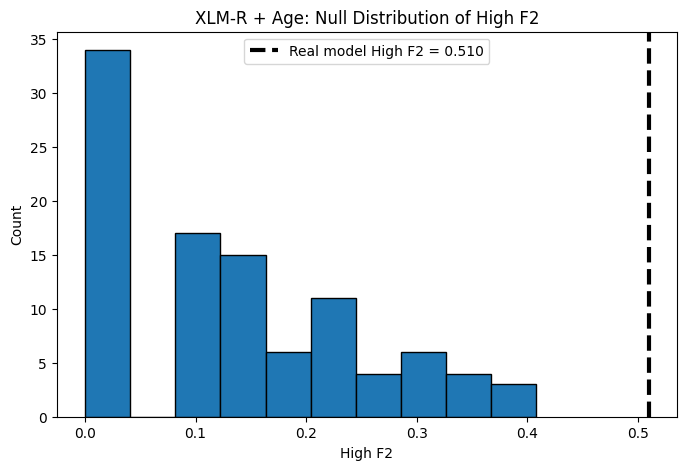

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    xlmr_null_100["high_f2"],
    bins=10,
    edgecolor="black"
)

plt.axvline(
    real_high_f2,
    linewidth=3,
    linestyle='--',
    color='black',
    label=f"Real model High F2 = {real_high_f2:.3f}"
)

plt.xlabel("High F2")
plt.ylabel("Count")
plt.title("XLM-R + Age: Null Distribution of High F2")
plt.legend()
plt.show()

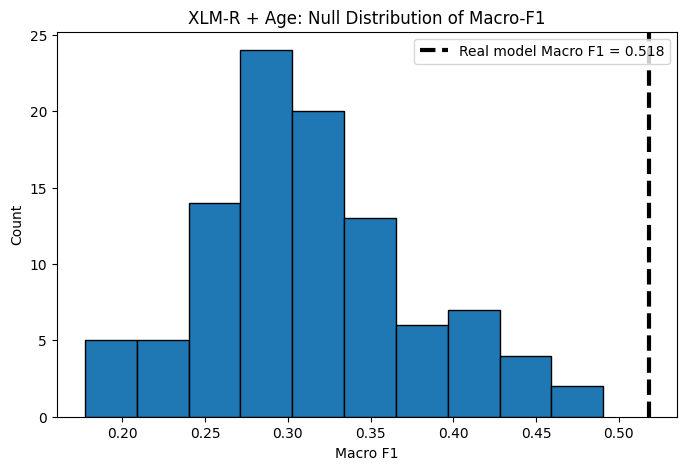

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    xlmr_null_100["macro_f1"],
    bins=10,
    edgecolor="black"
)

plt.axvline(
    real_macro_f1,
    linewidth=3,
    linestyle='--',
    color='black',
    label=f"Real model Macro F1 = {real_macro_f1:.3f}"
)

plt.xlabel("Macro F1")
plt.ylabel("Count")
plt.title("XLM-R + Age: Null Distribution of Macro-F1")
plt.legend()
plt.show()

### 3.2 Qualitative Error Analysis

To better understand the behavior of the final XLM-RoBERTa model, we examine errors involving the High-CBCL class, which is the primary class of interest in this study.

In [ ]:
best_predictions = results_event_eer_meta_partial_50["predictions_df"].copy()

best_predictions.head()

,y_true,y_pred,proba_Low,proba_Medium,proba_High,correct,input_text,CBCL_score
0,Medium,Low,0.369759,0.282818,0.347423,False,"EVENT: אין אירוע ספציפי, בעיקר חוסר סבלנות וכע...",14.0
1,Low,Low,0.360636,0.319877,0.319487,True,EVENT: היום הראשון. ראיתי בנייד תמונות וסרטוני...,6.0
2,High,Low,0.403180,0.319759,0.277061,False,"EVENT: פחדים חרדות , אי שקט קושי בשינה \n\nEER...",46.0
3,Low,High,0.340666,0.290395,0.368940,False,EVENT: חוסר הרצון של הילדים ללכת לבית ספר. תחו...,13.0
4,Medium,Medium,0.343523,0.446091,0.210386,True,EVENT: הבת שלי פחדה מאוד מחדירת מחבלים לממד של...,17.0


#### 3.2.1 Error-Type Distribution

In [ ]:
best_predictions["error_type"] = np.where(
    best_predictions["y_true"] == best_predictions["y_pred"],
    "Correct",
    best_predictions["y_true"] + " -> " + best_predictions["y_pred"]
)

best_predictions["error_type"].value_counts()

,count
error_type,
Correct,29
Medium -> Low,8
Low -> Medium,5
Medium -> High,4
Low -> High,4
High -> Low,2
High -> Medium,2


In [ ]:
def print_cases(df, title, max_cases=10):
    print("=" * 120)
    print(title)
    print("=" * 120)

    for i, row in df.head(max_cases).iterrows():
        print("\n" + "-" * 120)
        print(f"TRUE: {row['y_true']} | PRED: {row['y_pred']} | CBCL: {row.get('CBCL_score', 'NA')}")
        print(
            f"P(Low)={row['proba_Low']:.3f} | "
            f"P(Medium)={row['proba_Medium']:.3f} | "
            f"P(High)={row['proba_High']:.3f}"
        )
        print("\nINPUT TEXT:")
        print(row["input_text"])

In [ ]:
correct_high = best_predictions[
    (best_predictions["y_true"] == "High") &
    (best_predictions["y_pred"] == "High")
].copy()


In [ ]:
print_cases(correct_high, "Correct High cases")

Correct High cases

------------------------------------------------------------------------------------------------------------------------
TRUE: High | PRED: High | CBCL: 44.0
P(Low)=0.309 | P(Medium)=0.345 | P(High)=0.346

INPUT TEXT:
EVENT: המטפלת של הבת שלי התקשרה ושיתפה שהסת ךשי שיתפה אותה שיש לה מחשבות אובדניות. שוחחנו עם הבת והיינו איתה בזה. הרגשתי נורא. חוסר אונים. כישלון. עצב ויאוש

EER_TEXT: את אמא טובה. פשוט טובה. את רואה את הבת שלך ונוכחת עבורה. הקושי העצום שלה לא מעיד עליך אם את טובה. ההתמודדות שלך מעידה עליך ושם היית מדהימה.
את תצטרכי הרבה כוח להתמודדות הזו ואני יודעת שיהיו לך כוחות ואת תצליחי להיות עם הלב שלך ןעם הלב שלה ןלעזור לה.

METADATA: child_age=15

------------------------------------------------------------------------------------------------------------------------
TRUE: High | PRED: High | CBCL: 55.0
P(Low)=0.363 | P(Medium)=0.259 | P(High)=0.378

INPUT TEXT:
EVENT: בגלל המערכה נאלצתי לחפש תעסוקה לילדים שלי בגלל שאין ביה"ס וזה גרם לי לסטרס/דאגות יום יומייות ו

In [ ]:
missed_high = best_predictions[
    (best_predictions["y_true"] == "High") &
    (best_predictions["y_pred"] != "High")
].copy()


In [ ]:
print_cases(missed_high, "Missed High cases")

Missed High cases

------------------------------------------------------------------------------------------------------------------------
TRUE: High | PRED: Low | CBCL: 46.0
P(Low)=0.403 | P(Medium)=0.320 | P(High)=0.277

INPUT TEXT:
EVENT: פחדים חרדות , אי שקט קושי בשינה 

EER_TEXT: יהיו ימים טובים , כל החטופים יחזרו הביתה בשלום 
שלא יהיו לנו אויבים 

METADATA: child_age=10

------------------------------------------------------------------------------------------------------------------------
TRUE: High | PRED: Medium | CBCL: 32.0
P(Low)=0.349 | P(Medium)=0.403 | P(High)=0.248

INPUT TEXT:
EVENT: בזמן אזעקה מחוץ לבית עם יךדי הקטניפ , הרגשה של חוזר אונים בשמירה על ילדי

EER_TEXT: מצטער צאוד אך קשה לי עם זה

METADATA: child_age=6

------------------------------------------------------------------------------------------------------------------------
TRUE: High | PRED: Low | CBCL: 35.0
P(Low)=0.430 | P(Medium)=0.267 | P(High)=0.303

INPUT TEXT:
EVENT: שחשפתי את ילדי לארועי המלחמה

EER

In [ ]:
false_high = best_predictions[
    (best_predictions["y_true"] != "High") &
    (best_predictions["y_pred"] == "High")
].copy()


In [ ]:
print_cases(false_high, "False High cases")

False High cases

------------------------------------------------------------------------------------------------------------------------
TRUE: Low | PRED: High | CBCL: 13.0
P(Low)=0.341 | P(Medium)=0.290 | P(High)=0.369

INPUT TEXT:
EVENT: חוסר הרצון של הילדים ללכת לבית ספר. תחושה שלהם של נתק ואי הבנה למה צריך ללמוד

EER_TEXT: הכל זמני וזה יעבור
תמשיכי לדבר עם הילדים ולהסביר להם את חשיבות הלמידה הפרונטלית גם בתקופה זו

METADATA: child_age=16

------------------------------------------------------------------------------------------------------------------------
TRUE: Low | PRED: High | CBCL: 3.0
P(Low)=0.330 | P(Medium)=0.287 | P(High)=0.382

INPUT TEXT:
EVENT: בגלל שאין מסגרות הילד כל היום מול מסכים מה שפוגע בהתפתחות ובפועל אין לי יותר מידי מה לעשות או את הכלים

EER_TEXT: החזרתי את הילד למסגרת למרות שזה בשעות צומצמות וממש מרגישה שזה עושה לו טוב והוא התגעגע לגן 

METADATA: child_age=5

---------------------------------------------------------------------------------------------------

In [ ]:
extreme_errors = best_predictions[
    best_predictions["error_type"].isin([
        "High -> Low",
        "Low -> High"
    ])
].copy()


In [ ]:
print_cases(extreme_errors, "Extreme errors: High->Low and Low->High")

Extreme errors: High->Low and Low->High

------------------------------------------------------------------------------------------------------------------------
TRUE: High | PRED: Low | CBCL: 46.0
P(Low)=0.403 | P(Medium)=0.320 | P(High)=0.277

INPUT TEXT:
EVENT: פחדים חרדות , אי שקט קושי בשינה 

EER_TEXT: יהיו ימים טובים , כל החטופים יחזרו הביתה בשלום 
שלא יהיו לנו אויבים 

METADATA: child_age=10

------------------------------------------------------------------------------------------------------------------------
TRUE: Low | PRED: High | CBCL: 13.0
P(Low)=0.341 | P(Medium)=0.290 | P(High)=0.369

INPUT TEXT:
EVENT: חוסר הרצון של הילדים ללכת לבית ספר. תחושה שלהם של נתק ואי הבנה למה צריך ללמוד

EER_TEXT: הכל זמני וזה יעבור
תמשיכי לדבר עם הילדים ולהסביר להם את חשיבות הלמידה הפרונטלית גם בתקופה זו

METADATA: child_age=16

------------------------------------------------------------------------------------------------------------------------
TRUE: Low | PRED: High | CBCL: 3.0
P(Low)=0.3

## 4. Research Extension: Ordinal CORN Model

The research extension reformulates CBCL severity prediction as an ordinal classification problem using CORN (Conditional Ordinal Regression for Neural Networks). Unlike standard multiclass cross-entropy, CORN explicitly incorporates the ordered relationship between Low, Medium, and High severity levels through conditional binary tasks. We apply this approach using the same frozen XLM-RoBERTa backbone, text inputs, child-age metadata, and oversampling strategy used for the best multiclass model.

In [ ]:
from transformers_corn_modeling import run_corn_experiment

### 4.1 CORN Experiment

In [ ]:
results_corn_child_age = run_corn_experiment(
    train_df=train_df,
    test_df=test_df,
    mode="event_eer",
    model_name="xlm-roberta-base",
    output_dir="./corn_event_eer_child_age_partial_50",
    max_length=384,
    num_epochs=20,
    batch_size=8,
    learning_rate=1e-3,
    freeze_base_model=True,
    oversample_train=True,
    oversample_target_counts={
        0: 89,
        1: 70,
        2: 50
    },
    metadata_columns=["child_age"],
    threshold=0.5
)

Running CORN ordinal transformer experiment
Mode: event_eer
Model: xlm-roberta-base
Freeze base model: True
Oversample inner train: True
Metadata columns: ['child_age']
Threshold: 0.5
Output layer: 2 logits for CORN ordinal tasks

Before oversampling:
Low       89
Medium    58
High      25
Name: count, dtype: int64

After oversampling:
Low       89
Medium    70
High      50
Name: count, dtype: int64

Final data sizes:
Inner train size: 209
Validation size: 44
Test size: 54


Map:   0%|          | 0/209 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,High Precision,High Recall,High F2,Mae,Rmse
1,0.774321,0.684865,0.386364,0.228772,0.000000,0.000000,0.000000,0.613636,0.783349
2,0.757398,0.663495,0.477273,0.337321,0.000000,0.000000,0.000000,0.545455,0.768706
3,0.717808,0.688605,0.340909,0.169492,0.000000,0.000000,0.000000,0.659091,0.811844
4,0.701484,0.715365,0.340909,0.169492,0.000000,0.000000,0.000000,0.659091,0.811844
5,0.712806,0.687385,0.340909,0.169492,0.000000,0.000000,0.000000,0.659091,0.811844
6,0.658682,0.679303,0.340909,0.169492,0.000000,0.000000,0.000000,0.659091,0.811844
7,0.682994,0.735457,0.340909,0.169492,0.000000,0.000000,0.000000,0.659091,0.811844
8,0.682533,0.711326,0.409091,0.255495,0.000000,0.000000,0.000000,0.590909,0.768706
9,0.664530,0.661107,0.409091,0.255495,0.000000,0.000000,0.000000,0.590909,0.768706
10,0.660946,0.707393,0.409091,0.255495,0.000000,0.000000,0.000000,0.590909,0.768706



Validation evaluation after final epoch:


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,High Precision,High Recall,High F2,Mae,Rmse
0.602261,0.677245,20,0.409091,0.255495,0.000000,0.000000,0.000000,0.590909,0.768706


{'eval_loss': 0.6772445440292358, 'eval_accuracy': 0.4090909090909091, 'eval_macro_f1': 0.2554945054945055, 'eval_high_precision': 0.0, 'eval_high_recall': 0.0, 'eval_high_f2': 0.0, 'eval_mae': 0.5909090909090909, 'eval_rmse': 0.7687061147858074}



TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        24
      Medium       0.39      1.00      0.56        21
        High       0.00      0.00      0.00         9

    accuracy                           0.39        54
   macro avg       0.13      0.33      0.19        54
weighted avg       0.15      0.39      0.22        54


TEST SUMMARY METRICS
Accuracy:        0.389
Macro F1:        0.187
High Precision:  0.000
High Recall:     0.000
High F2:         0.000
MAE:             0.611
RMSE:            0.782

TEST CONFUSION MATRIX
             Pred Low  Pred Medium  Pred High
True Low            0           24          0
True Medium         0           21          0
True High           0            9          0


In this application, the ordinal CORN formulation did not improve prediction performance. At the default decision threshold of 0.5, the model collapsed to predicting the Medium class for all test observations, resulting in substantially lower Macro F1 and no successful identification of High-CBCL cases. Thus, explicitly modeling the ordering of the outcome did not provide an advantage over the standard multiclass XLM-RoBERTa model in this dataset.